# Challenge: Analyzing Text about Data Science

In this example, let's do a simple exercise that covers all steps of a traditional data science process. You do not have to write any code, you can just click on the cells below to execute them and observe the result. As a challenge, you are encouraged to try this code out with different data. 

## Goal

In this lesson, we have been discussing different concepts related to Data Science. Let's try to discover more related concepts by doing some **text mining**. We will start with a text about Data Science, extract keywords from it, and then try to visualize the result.

As a text, I will use the page on Data Science from Wikipedia:

In [1]:
url = 'https://en.wikipedia.org/wiki/Data_science'

## Step 1: Getting the Data

First step in every data science process is getting the data. We will use `requests` library to do that:

In [ ]:
import requests
headers = {"User-Agent": "Microsoft DS4Beginners/ Github Link: https://github.com/Dre-J"}
text = requests.get(url, headers=headers).content.decode('utf-8')
print(text[:1000])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available skin-theme-clientpref-thumb-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Data science - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limit

## Step 2: Transforming the Data

The next step is to convert the data into the form suitable for processing. In our case, we have downloaded HTML source code from the page, and we need to convert it into plain text.

There are many ways this can be done. We will use [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/), a popular Python library for parsing HTML. BeautifulSoup allows us to target specific HTML elements, so we can focus on the main article content from Wikipedia and reduce some navigation menus, sidebars, footers, and other irrelevant content (though some boilerplate text may still remain).

First, we need to install the BeautifulSoup library for HTML parsing:

In [3]:
import sys
!{sys.executable} -m pip install beautifulsoup4


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [6]:
from bs4 import BeautifulSoup

# Parse the HTML content
soup = BeautifulSoup(text, 'html.parser')

# Extract only the main article content from Wikipedia
# Wikipedia uses 'mw-parser-output' class for the main article content
content = soup.find('div', class_='mw-parser-output')

def clean_wikipedia_content(content_node):
    """Remove common non-article elements from a Wikipedia content node."""
    # Strip jump links, navboxes, reference lists/superscripts, edit sections, TOC, sidebars, etc.
    selectors = [
        '.mw-jump-link',
        '.navbox',
        '.reflist',
        'sup.reference',
        '.mw-editsection',
        '.hatnote',
        '.metadata',
        '.infobox',
        '#toc',
        '.toc',
        '.sidebar',
    ]
    for selector in selectors:
        for el in content_node.select(selector):
            el.decompose()

if content:
    # Clean the content node to better approximate article text only.
    clean_wikipedia_content(content)
    text = content.get_text(separator=' ', strip=True)
    print(text[:1000])
else:
    print("Could not find main content. Using full page text.")
    text = soup.get_text(separator=' ', strip=True)
    print(text[:1000])

Field of study to extract knowledge from data The existence of Comet NEOWISE (here depicted as a series of red dots) was discovered by analyzing astronomical survey data acquired by a space telescope , the Wide-field Infrared Survey Explorer . Data science is an interdisciplinary academic field that uses statistics , scientific computing , scientific methods , processing, scientific visualization , algorithms , and systems to extract or extrapolate knowledge from potentially noisy, structured , or unstructured data . Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine). Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession. Data science is "a concept to unify statistics , data analysis , informatics , and their related methods " to "understand and analyze actual phenomena " with data . It uses techniq

## Step 3: Getting Insights

The most important step is to turn our data into some form from which we can draw insights. In our case, we want to extract keywords from the text, and see which keywords are more meaningful.

We will use Python library called [RAKE](https://github.com/aneesha/RAKE) for keyword extraction. First, let's install this library in case it is not present: 

In [7]:
import sys
!{sys.executable} -m pip install nlp_rake

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 27.4 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 61.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.0/802.0 kB 40.3 MB/s  0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993332 sha256=ad1ff4f952fff97bbbd6d03eb33b1cce9d97bcf5689d9728a637951bfa0abf95
  Stored in directory: /home/codespace/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
   ━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

The main functionality is available from `Rake` object, which we can customize using some parameters. In our case, we will set the minimum length of a keyword to 5 characters, minimum frequency of a keyword in the document to 3, and maximum number of words in a keyword - to 2. Feel free to play around with other values and observe the result.

In [8]:
import nlp_rake
extractor = nlp_rake.Rake(max_words=2,min_freq=3,min_chars=5)
res = extractor.apply(text)
res

[('data scientist', 4.0),
 ('sexiest job', 4.0),
 ('21st century', 4.0),
 ('statistical learning', 4.0),
 ('big data', 4.0),
 ('data science', 3.9047619047619047),
 ('computer science', 3.9047619047619047),
 ('^ davenport', 3.8),
 ('information science', 3.738095238095238),
 ('data analysis', 3.7272727272727275),
 ('cloud computing', 3.666666666666667),
 ('science', 1.9047619047619047),
 ('analysis', 1.7272727272727273),
 ('computing', 1.6666666666666667),
 ('sciences', 1.4),
 ('statistics', 1.3),
 ('processing', 1.25),
 ('education', 1.25),
 ('field', 1.2),
 ('thomas', 1.2),
 ('study', 1.0),
 ('techniques', 1.0),
 ('report', 1.0),
 ('process', 1.0),
 ('david', 1.0),
 ('communications', 1.0),
 ('chikio', 1.0),
 ('bibcode', 1.0)]


We obtained a list terms together with associated degree of importance. As you can see, the most relevant disciplines, such as machine learning and big data, are present in the list at top positions.

## Step 4: Visualizing the Result

People can interpret the data best in the visual form. Thus it often makes sense to visualize the data in order to draw some insights. We can use `matplotlib` library in Python to plot simple distribution of the keywords with their relevance:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 50.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 62.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 86.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


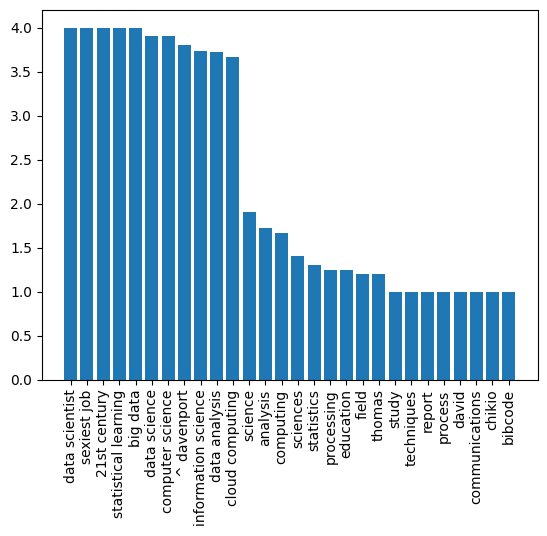

In [ ]:
#!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt

def plot(pair_list):
    k,v = zip(*pair_list)
    plt.bar(range(len(k)),v)
    plt.xticks(range(len(k)),k,rotation='vertical')
    plt.show()

plot(res)

There is, however, even better way to visualize word frequencies - using **Word Cloud**. We will need to install another library to plot the word cloud from our keyword list.

In [11]:
!{sys.executable} -m pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 3.5 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


`WordCloud` object is responsible for taking in either original text, or pre-computed list of words with their frequencies, and returns and image, which can then be displayed using `matplotlib`:

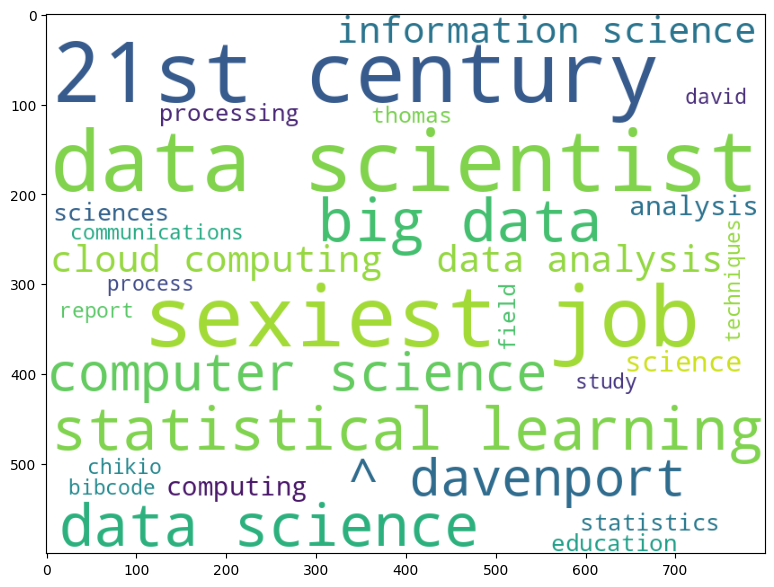

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(background_color='white',width=800,height=600)
plt.figure(figsize=(15,7))
plt.imshow(wc.generate_from_frequencies({ k:v for k,v in res }))

We can also pass in the original text to `WordCloud` - let's see if we are able to get similar result:

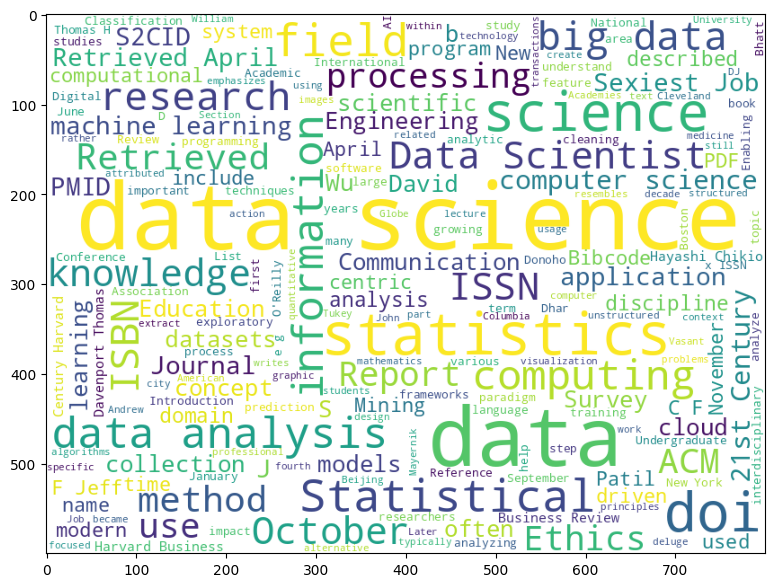

In [14]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(text))

In [15]:
wc.generate(text).to_file('images/ds_wordcloud.png')

You can see that word cloud now looks more impressive, but it also contains a lot of noise (eg. unrelated words such as `Retrieved on`). Also, we get fewer keywords that consist of two words, such as *data scientist*, or *computer science*. This is because RAKE algorithm does much better job at selecting good keywords from text. This example illustrates the importance of data pre-processing and cleaning, because clear picture at the end will allow us to make better decisions.

In this exercise we have gone through a simple process of extracting some meaning from Wikipedia text, in the form of keywords and word cloud. This example is quite simple, but it demonstrates well all typical steps a data scientist will take when working with data, starting from data acquisition, up to visualization.

In our course we will discuss all those steps in detail. 